## 1) 设定环境并读取基本信息
解析 `dataset_info.json` 以动态获取数据特征（通道数、采样点、类别等），消除硬编码。

In [11]:
import json
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import copy
from torch.utils.data import DataLoader

# 假设自定义的 Dataset 路径已正确配置
from course_project.TEST_DATASET import TrainDataset, TestDataset

DATA_NAME = "BCIC2A" 
DATA_INFO_PATH = f"course_project/{DATA_NAME}/dataset_info.json"
INDEX_PATH_TRAIN = f"course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"course_project/{DATA_NAME}/test_x_only.h5"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

num_labels = info["dataset"]["num_labels"]
category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Information ===")
print("Number of Labels:", num_labels)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

# 动态确定输入特征维度
time_points = int(target_sampling_rate * window_sec)
num_channels = len(channels)
num_classes = num_labels

=== Dataset Information ===
Number of Labels: 4
Categories: ['left', 'right', 'foot', 'tongue']
Channels (count): 22
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 2) 检查数据形状

In [12]:
print("========== 检查训练集 (Train) ==========")
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查验证集 (Validation) ==========")
with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查测试集 (Test - X only) ==========")
with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)

========== 检查训练集 (Train) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (720, 22, 800)
y dtype: int64
y shape: (720,)
unique: [0 1 2 3]

========== 检查验证集 (Validation) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (360, 22, 800)
y dtype: int64
y shape: (360,)
unique: [0 1 2 3]

========== 检查测试集 (Test - X only) ==========
keys: ['X']
x dtype: float32
x shape: (360, 22, 800)


## 3) 定义模型
最终模型：**ATCNet**

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TCNDilatedBlock(nn.Module):
    """
    TCN (Temporal Convolutional Network) 中的膨胀卷积残差块
    通过不同的膨胀率(Dilation)获得指数级扩大的感受野，专门用于捕获长程时序依赖
    """
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.3):
        super(TCNDilatedBlock, self).__init__()
        # 为了保证卷积后序列长度不变 (same padding)
        padding = (kernel_size - 1) * dilation // 2 
        
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(channels)
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        out = F.elu(self.bn1(self.conv1(x)))
        out = self.dropout1(out)
        out = self.bn2(self.conv2(out))
        # 残差连接
        out = F.elu(out + residual)
        out = self.dropout2(out)
        return out


class ATCNet(nn.Module):
    """
    ATCNet: Attention-Based Temporal Convolutional Network
    架构流：局部空时CNN -> 多头自注意力(MHA) -> 多层膨胀TCN -> 全连接层
    """
    def __init__(self, input_channels, num_classes, time_points=200):
        super(ATCNet, self).__init__()
        
        # ==========================================
        # 1. CNN 块 (Conv Block)
        # ==========================================
        self.temporal_conv = nn.Conv2d(1, 16, kernel_size=(1, 31), padding=(0, 15), bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        self.spatial_conv = nn.Conv2d(16, 16, kernel_size=(input_channels, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(16)
        
        # 时间维度池化，将高频信号降维
        self.pool = nn.AvgPool2d((1, 4))
        self.dropout_cnn = nn.Dropout(0.3)

        # 动态推导池化后的序列长度
        with torch.no_grad():
            dummy_x = torch.zeros(1, 1, input_channels, time_points)
            dummy_x = self.temporal_conv(dummy_x)
            dummy_x = self.spatial_conv(dummy_x)
            dummy_x = self.pool(dummy_x)
            # (Batch, Features, 1, Seq_len)
            _, d_model, _, seq_len = dummy_x.shape
            
        self.d_model = d_model  # 16维
        self.seq_len = seq_len

        # ==========================================
        # 2. 注意力块 (Attention Block)
        # ==========================================
        # 在整个时间序列上进行多头注意力机制，寻找最显著的时序片段
        self.attention = nn.MultiheadAttention(embed_dim=self.d_model, num_heads=2, dropout=0.3, batch_first=True)
        self.norm = nn.LayerNorm(self.d_model)

        # ==========================================
        # 3. 时间卷积网络 (TCN Block)
        # ==========================================
        # 级联多个 TCN 块，膨胀率呈指数增长 (1, 2, 4)
        self.tcn = nn.Sequential(
            TCNDilatedBlock(channels=self.d_model, kernel_size=3, dilation=1),
            TCNDilatedBlock(channels=self.d_model, kernel_size=3, dilation=2),
            TCNDilatedBlock(channels=self.d_model, kernel_size=3, dilation=4)
        )

        # ==========================================
        # 4. 分类器
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(self.d_model, 32),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x 输入: (B, C, T) -> (B, 1, C, T)
        x = x.unsqueeze(1)
        
        # --- 1. CNN Block ---
        x = self.temporal_conv(x)
        x = F.elu(self.bn1(x))
        x = self.spatial_conv(x)
        x = F.elu(self.bn2(x))
        x = self.pool(x)
        x = self.dropout_cnn(x)
        
        # 降维并转换通道以适配 Attention: (B, 16, 1, Seq) -> (B, Seq, 16)
        x = x.squeeze(2).permute(0, 2, 1)
        
        # --- 2. Attention Block ---
        # 注意力计算并使用残差连接
        attn_out, _ = self.attention(x, x, x)
        x = self.norm(x + attn_out)
        
        # 转换通道以适配 TCN (1D 卷积要求特征在中间维度): (B, Seq, 16) -> (B, 16, Seq)
        x = x.permute(0, 2, 1)
        
        # --- 3. TCN Block ---
        x = self.tcn(x)
        
        # --- 4. 聚合与分类 ---
        # 使用全局平均池化在时间维度上压缩: (B, 16, Seq) -> (B, 16)
        x = torch.mean(x, dim=2)
        logits = self.classifier(x)
        
        return logits

## 4) 配置数据加载器、设备与优化器
设备自适应检测（CUDA GPU / Apple MPS / CPU）

In [14]:
# -------------------------
# 超参数设定
# -------------------------
BATCH_SIZE = 64
EPOCHS = 200          # 增加总 Epoch 数，依靠早停来控制结束
LR = 1e-3
PATIENCE = 20        # 早停的耐心值（验证集持续多少轮不上升则停止）

# -------------------------
# 设定计算设备 (GPU / MPS / CPU)
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# -------------------------
# 准备 DataLoader
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# 新增： 动态获取真实的 time_points，彻底避免维度不匹配
sample_x, _ = train_ds[0]  
real_time_points = sample_x.shape[1] 

if real_time_points != time_points:
    print(f"检测到真实的采样点长度 (Time Points): {real_time_points}，与预设值 {time_points} 不一致")

# -------------------------
# 实例化模型、损失函数、优化器
# -------------------------
model = ATCNet(
    input_channels=num_channels,
    time_points=real_time_points,
    num_classes=num_classes
).to(device)

# [优化 1] 标签平滑 (Label Smoothing)：针对 BCI 噪声数据，防止模型过度自信
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# [优化 2] 增加 Weight Decay：从原先的 1e-4 提升到 1e-3，强力抑制过拟合
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)

# [优化 3] 余弦退火学习率调度器：让学习率平滑下降，解决验证集震荡问题
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

Using device: cpu
检测到真实的采样点长度 (Time Points): 800，与预设值 200 不一致


## 5) 模型训练与验证
实现了 **Early Stopping** 和 **Best Model 保存机制**。避免模型训练到最后已经严重过拟合。

In [15]:
# 用于记录曲线的数组
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

best_val_acc = 0.0
best_model_weights = None
epochs_no_improve = 0
has_saved_model = False
best_model_path = None 

os.makedirs("model_checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0  
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        
        # [优化 4] 梯度裁剪：强行截断过大的梯度，防止 loss 突然炸裂跳跃
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num  
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)     

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)
            
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # [优化关联] 学习率更新
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 打印每轮训练结果 (加入了当前学习率显示)
    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | LR: {current_lr:.5f} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2%} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2%}"
    )

    # ===== 早停与最佳模型保存逻辑 =====
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0  # 只要准确率刷新就重置耐心值
        
        # 从第 20 个 epoch 开始，并且超越了历史最佳才实际保存模型
        if epoch + 1 >= 20 and epoch_val_acc > 0.5:
            best_model_weights = copy.deepcopy(model.state_dict())
            # 为文件加上 Val Accuracy 的值作为后缀
            current_model_path = f"model_checkpoints/{DATA_NAME}_best_model_acc{best_val_acc * 100:.2f}.pth"
  
            # 先将删除旧权重，再更新模型路径并保存
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)
            best_model_path = current_model_path
            torch.save(best_model_weights, best_model_path)
            has_saved_model = True
            print(f" ---> 出现更高的验证集准确率 ({best_val_acc:.2%})，已更新模型。")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nTriggered Early Stopping at Epoch {epoch+1}!")
            break
            
    if epoch + 1 == 20:
        print(f" ---> 前 20 个 Epoch 结束，目前的最佳验证集准确率为 {best_val_acc:.2%}")

print("\n" + "-" * 40)
print(f"Final Best Val Accuracy: {best_val_acc:.2%}")

# 最终的结果打印判定
if has_saved_model:
    print(f"训练成功结束！最佳模型已保存至: {best_model_path}")
else:
    print("\n【提醒】训练结束但未保存模型！请调整代码。")

Epoch [001/200] | LR: 0.00100 | Train Loss: 1.4007 | Train Acc: 26.25% | Val Loss: 1.4033 | Val Acc: 25.00%
Epoch [002/200] | LR: 0.00100 | Train Loss: 1.3964 | Train Acc: 26.11% | Val Loss: 1.3908 | Val Acc: 25.56%
Epoch [003/200] | LR: 0.00100 | Train Loss: 1.3851 | Train Acc: 29.44% | Val Loss: 1.5252 | Val Acc: 25.00%
Epoch [004/200] | LR: 0.00100 | Train Loss: 1.3840 | Train Acc: 28.06% | Val Loss: 1.6203 | Val Acc: 25.00%
Epoch [005/200] | LR: 0.00100 | Train Loss: 1.3860 | Train Acc: 23.33% | Val Loss: 1.5030 | Val Acc: 25.00%
Epoch [006/200] | LR: 0.00100 | Train Loss: 1.3776 | Train Acc: 27.64% | Val Loss: 1.3685 | Val Acc: 32.22%
Epoch [007/200] | LR: 0.00100 | Train Loss: 1.3752 | Train Acc: 29.44% | Val Loss: 1.3565 | Val Acc: 33.89%
Epoch [008/200] | LR: 0.00100 | Train Loss: 1.3662 | Train Acc: 31.25% | Val Loss: 1.3656 | Val Acc: 31.39%
Epoch [009/200] | LR: 0.00100 | Train Loss: 1.3615 | Train Acc: 30.97% | Val Loss: 1.3524 | Val Acc: 35.28%
Epoch [010/200] | LR: 0.0009

## 6) 训练过程可视化

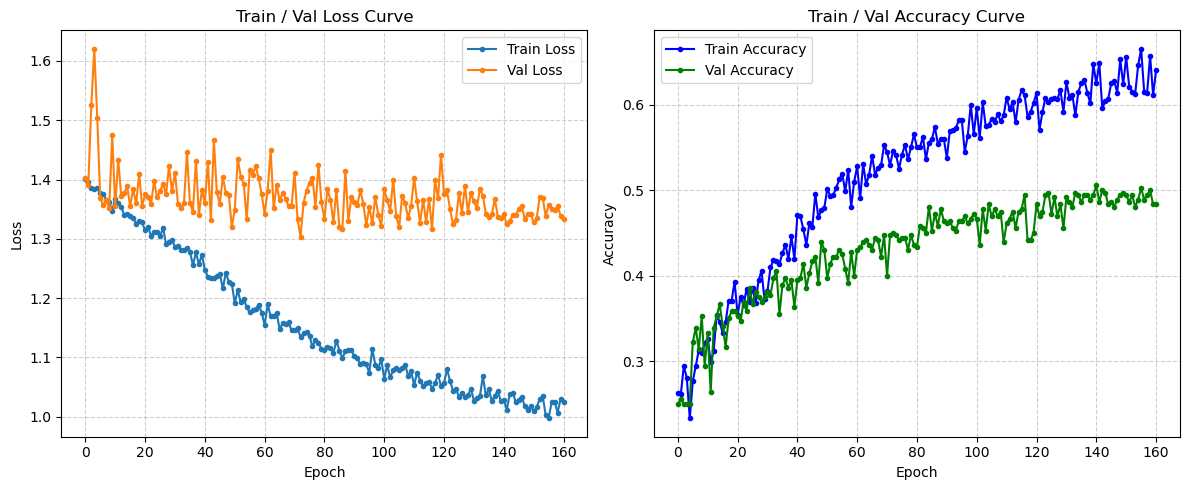

In [16]:
plt.figure(figsize=(12, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses, label="Val Loss", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", marker='o', markersize=3, color='blue')
plt.plot(val_accuracies, label="Val Accuracy", marker='o', markersize=3, color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve") 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 7) 测试集推理与结果生成
执行测试推理前，将回载上面跑出来的“最佳验证集权重”，以此来产出最终提交的结果。

In [17]:
os.makedirs("final_result", exist_ok=True)
# -------------------------
# 加载最佳模型权重
# -------------------------
# 方式 1 ：使用训练过程中保存的最佳模型路径
model_path = best_model_path  
# 方式 2 ：手动指定 model_checkpoints 文件夹下的模型路径
# model_path = "model_checkpoints/CHINESE_best_model_acc51.50.pth"  

print(f"Loading best model from {model_path} for testing...")
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

model.eval()

output_path = f'final_result/{DATA_NAME}.txt'
all_test_labels = []

with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_data = test_data.to(device)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

# 保存 test 预测标签（每行一个数字）
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

Loading best model from model_checkpoints/BCIC2A_best_model_acc50.56.pth for testing...
Saved 360 labels to: final_result/BCIC2A.txt
